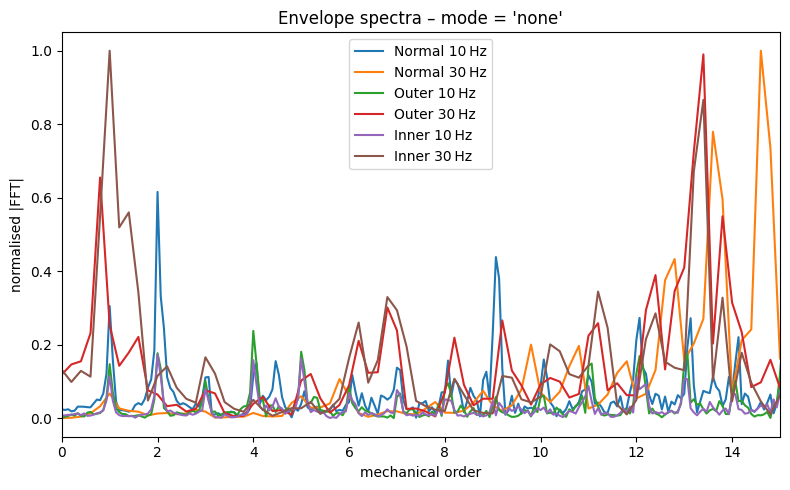

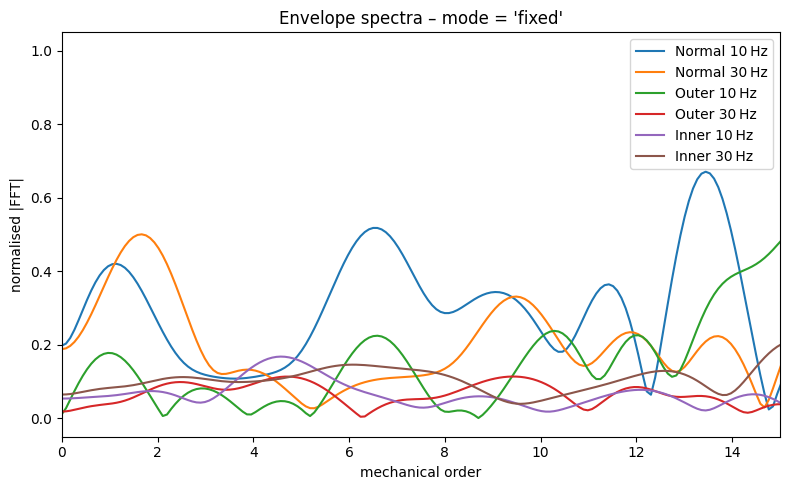

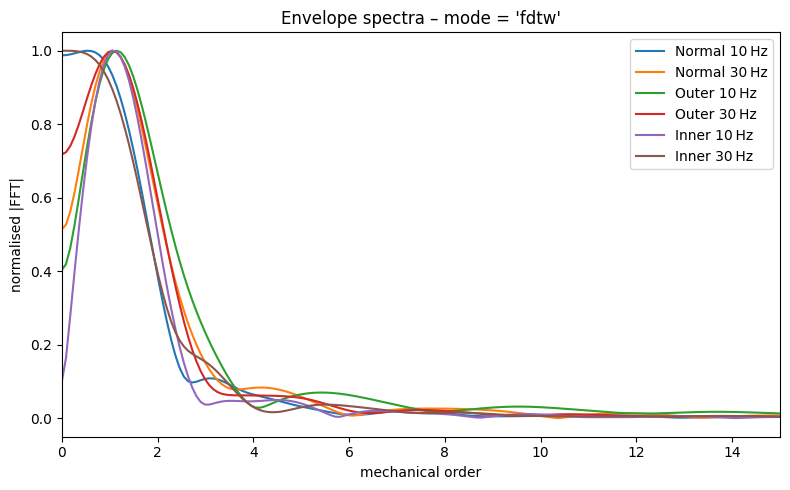

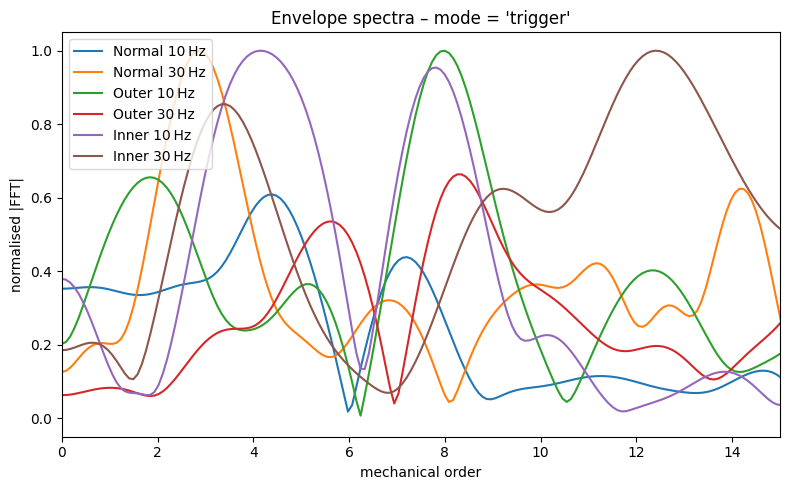

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from brf_lightning.data.bearing.bearing import BearingDataModule
from brf_lightning.data.bearing.utils import load_vibration_data

# ------------------------------------------------------------------
# helper: compute order‑spectrum magnitude for one 1‑D window
# ------------------------------------------------------------------
def order_spectrum(x: np.ndarray, fs: float, speed: float, nfft: int = 4096):
    """Return (orders, |FFT|) for a window.

    Works for both time‑domain (speed > 1) and angle‑domain
    (speed == 1, fs == samples_per_rev).
    """
    x = x.astype(np.float32)
    x = x * np.hanning(len(x))                # gentle window
    spec = np.abs(np.fft.rfft(x, n=nfft))
    freq = np.fft.rfftfreq(nfft, d=1 / fs)
    orders = freq / speed
    return orders, spec / spec.max()          # normalised for plotting


# ------------------------------------------------------------------
# settings ----------------------------------------------------------
modes = ["none", "fixed", "fdtw", "trigger"]             # order‑domain strategies
files = [
    ("n10" , "Normal 10 Hz", 10),
    ("n30" , "Normal 30 Hz", 30),
    ("fAII10", "Outer 10 Hz", 10),
    ("fAII30", "Outer 30 Hz", 30),
    ("fIII10", "Inner 10 Hz", 10),
    ("fIII30", "Inner 30 Hz", 30),
]
base = Path("data/bearing_thl_v1")

samples_per_rev = 360
win_sec = 1.0

# ------------------------------------------------------------------
for mode in modes:
    dm = BearingDataModule(
        filepaths=[base/f"{name}.csv" for name, _, _ in files],
        batch_size=1,
        window_size=win_sec,
        hop_size=win_sec,
        norm="global",
        target_rms=None,
        order_domain_mode=mode,
        samples_per_rev=samples_per_rev,
        balance_mode="none",
        keep_fraction=0.01,
        num_workers=0,          # notebook
    )
    dm.setup()

    batch_iter = iter(dm.train_dataloader())

    plt.figure(figsize=(8, 5))
    plt.title(f"Envelope spectra – mode = '{mode}'")
    plt.xlabel("mechanical order"); plt.ylabel("normalised |FFT|")
    plt.xlim(0, 15)

    for (fname, label, speed_nom) in files:
        # pull first slice of that file
        xb, yb, sb = next(batch_iter)
        x = xb[0, :, 0].numpy()
        speed_eff = float(sb[0].item())

        # fs_effective comes from dm internal knowledge
        fs_eff = dm.samples_per_rev if mode != "none" else 8192.0

        orders, spec = order_spectrum(x, fs_eff, speed_eff)
        plt.plot(orders, spec, label=label)

    plt.legend()
    plt.tight_layout()
    plt.show()
